# 🪸 Coral Bleaching Prediction — ConvLSTM
**Model:** ConvLSTM learns spatial patterns AND temporal trends simultaneously

**Difference from CNN+LSTM:** CNN+LSTM separates feature extraction and time learning. ConvLSTM does both at once inside each cell — more powerful for spatiotemporal data.

**Input:** 7 consecutive days × (4, 224, 224) stacked images

**Output:** BAA label (0–4)

**Train:** 2018–2023 | **Test:** 2024–2025

## Step 1: Upload Dataset

In [1]:
from google.colab import files
import zipfile, os

print("Click 'Choose Files' and select 3_dataset.zip ...")
uploaded = files.upload()  # button appears here

# Unzip
with zipfile.ZipFile('3_dataset.zip', 'r') as z:
    z.extractall('.')
print('Unzipped!')

# Set paths
DATASET_DIR = '/content/3_dataset'
SAVE_DIR    = '/content/4_models'
RESULTS_DIR = '/content/5_results'

os.makedirs(SAVE_DIR,    exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Dataset ready!')
print('Train files:', len(os.listdir(f'{DATASET_DIR}/train')))
print('Test files: ', len(os.listdir(f'{DATASET_DIR}/test')))

Click 'Choose Files' and select 3_dataset.zip ...


Saving 3_dataset.zip to 3_dataset.zip
Unzipped!
Dataset ready!
Train files: 1915
Test files:  727


## Step 2: Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


## Step 3: Dataset Loader (same as CNN+LSTM)

In [3]:
class CoralSequenceDataset(Dataset):
    """
    Loads sequences of 7 consecutive days.
    Input shape:  (7, 4, 224, 224)
    Label:        BAA value of the LAST day in sequence
    """
    def __init__(self, dataset_dir, labels_csv, seq_len=7):
        self.dataset_dir = dataset_dir
        self.seq_len     = seq_len

        df = pd.read_csv(labels_csv)
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)

        valid = []
        for _, row in df.iterrows():
            d    = row['date']
            path = f"{dataset_dir}/stacked_{d.year}_{d.month:02d}_{d.day:02d}.npy"
            if os.path.exists(path):
                valid.append({'date': d, 'label': int(row['label']), 'path': path})

        self.records = valid
        print(f'  Valid samples: {len(self.records)}')
        print(f'  Sequences of {seq_len} days: {len(self.records) - seq_len + 1}')

    def __len__(self):
        return len(self.records) - self.seq_len + 1

    def __getitem__(self, idx):
        frames = []
        for i in range(self.seq_len):
            arr = np.load(self.records[idx + i]['path'])  # (4, 224, 224)
            frames.append(arr)
        sequence = np.stack(frames, axis=0)               # (7, 4, 224, 224)
        label    = self.records[idx + self.seq_len - 1]['label']
        return torch.tensor(sequence, dtype=torch.float32), torch.tensor(label, dtype=torch.long)


SEQ_LEN    = 7
BATCH_SIZE = 8   # smaller than CNN+LSTM because ConvLSTM uses more memory

print('Loading train dataset...')
train_dataset = CoralSequenceDataset(
    f'{DATASET_DIR}/train',
    f'{DATASET_DIR}/train_labels.csv',
    seq_len=SEQ_LEN
)

print('\nLoading test dataset...')
test_dataset = CoralSequenceDataset(
    f'{DATASET_DIR}/test',
    f'{DATASET_DIR}/test_labels.csv',
    seq_len=SEQ_LEN
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'\nTrain batches: {len(train_loader)}')
print(f'Test batches:  {len(test_loader)}')

x, y = next(iter(train_loader))
print(f'\nBatch input shape: {x.shape}  → (batch, seq, channels, H, W)')
print(f'Batch label shape: {y.shape}')

Loading train dataset...
  Valid samples: 1915
  Sequences of 7 days: 1909

Loading test dataset...
  Valid samples: 727
  Sequences of 7 days: 721

Train batches: 239
Test batches:  91

Batch input shape: torch.Size([8, 7, 4, 224, 224])  → (batch, seq, channels, H, W)
Batch label shape: torch.Size([8])


## Step 4: Class Weights

In [4]:
all_labels = [train_dataset.records[i + SEQ_LEN - 1]['label']
              for i in range(len(train_dataset))]

classes = np.array([0, 1, 2, 3, 4])
weights = compute_class_weight('balanced', classes=classes, y=all_labels)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print('Class weights:')
for i, w in enumerate(weights):
    print(f'  Class {i}: {w:.3f}')

Class weights:
  Class 0: 0.661
  Class 1: 0.868
  Class 2: 1.720
  Class 3: 1.784
  Class 4: 0.839


## Step 5: ConvLSTM Model
Unlike CNN+LSTM where CNN and LSTM are separate, ConvLSTM uses **convolutional operations inside the LSTM gates** — it processes space and time together.

In [5]:
class ConvLSTMCell(nn.Module):
    """
    Single ConvLSTM cell.
    Instead of matrix multiplications like regular LSTM,
    it uses convolutions — so spatial structure is preserved.
    """
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.hidden_channels = hidden_channels
        padding = kernel_size // 2

        # All 4 gates in one conv (input, forget, cell, output)
        self.conv = nn.Conv2d(
            in_channels + hidden_channels,
            4 * hidden_channels,
            kernel_size=kernel_size,
            padding=padding
        )

    def forward(self, x, h, c):
        # x: (batch, in_channels, H, W)
        # h: (batch, hidden_channels, H, W)
        # c: (batch, hidden_channels, H, W)
        combined = torch.cat([x, h], dim=1)   # concat along channel dim
        gates    = self.conv(combined)         # (batch, 4*hidden, H, W)

        # Split into 4 gates
        i, f, g, o = gates.chunk(4, dim=1)

        i = torch.sigmoid(i)   # input gate
        f = torch.sigmoid(f)   # forget gate
        g = torch.tanh(g)      # cell gate
        o = torch.sigmoid(o)   # output gate

        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)

        return h_next, c_next


class CoralConvLSTM(nn.Module):
    """
    Full ConvLSTM model for coral bleaching prediction.
    Processes 7 days of 4-channel images spatiotemporally.
    """
    def __init__(self, in_channels=4, hidden_channels=32, num_classes=5):
        super().__init__()

        # Downsample input images first (224 → 28) to reduce memory
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 224 → 112
            nn.Conv2d(16, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 112 → 56
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 56 → 28
        )

        # ConvLSTM cell operates on (batch, hidden, 28, 28)
        self.convlstm = ConvLSTMCell(
            in_channels=hidden_channels,
            hidden_channels=hidden_channels,
            kernel_size=3
        )

        # Classifier on final hidden state
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),          # (hidden, 28, 28) → (hidden, 4, 4)
            nn.Flatten(),                          # → hidden * 4 * 4
            nn.Linear(hidden_channels * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: (batch, seq_len, 4, 224, 224)
        batch, seq_len, C, H, W = x.shape

        # Encode each frame: (batch, hidden, 28, 28)
        encoded = []
        for t in range(seq_len):
            enc = self.encoder(x[:, t])   # (batch, hidden, 28, 28)
            encoded.append(enc)

        # Init hidden and cell states with zeros
        _, hidden_ch, Hd, Wd = encoded[0].shape
        h = torch.zeros(batch, hidden_ch, Hd, Wd).to(x.device)
        c = torch.zeros(batch, hidden_ch, Hd, Wd).to(x.device)

        # Run through ConvLSTM over time
        for t in range(seq_len):
            h, c = self.convlstm(encoded[t], h, c)

        # Classify using final hidden state
        out = self.classifier(h)   # (batch, num_classes)
        return out


model = CoralConvLSTM(
    in_channels=4,
    hidden_channels=32,
    num_classes=5
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')

CoralConvLSTM(
  (encoder): Sequential(
    (0): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (convlstm): ConvLSTMCell(
    (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(4, 4))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.4, inplace=False)
    (5): Linear(in_features=128, out_features=5, bias=True)
  )
)

Total trainable para

## Step 6: Training Setup

In [6]:
EPOCHS = 30
LR     = 1e-3

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f'Training for {EPOCHS} epochs on {device}')
print(f'Batch size: {BATCH_SIZE} (smaller than CNN+LSTM due to ConvLSTM memory usage)')

Training for 30 epochs on cuda
Batch size: 8 (smaller than CNN+LSTM due to ConvLSTM memory usage)


## Step 7: Train the Model

In [7]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out  = model(X)
            loss = criterion(out, y)
            total_loss += loss.item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total


best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = eval_epoch(model,  test_loader,  criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'{SAVE_DIR}/convlstm_best.pth')

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}'
          + (' <- best saved' if val_acc == best_val_acc else ''))

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Epoch 01/30 | Train Loss: 1.3818  Acc: 0.4259 | Val Loss: 1.0370  Acc: 0.5506 <- best saved
Epoch 02/30 | Train Loss: 0.9568  Acc: 0.6412 | Val Loss: 1.1680  Acc: 0.5284
Epoch 03/30 | Train Loss: 0.7141  Acc: 0.7297 | Val Loss: 1.0810  Acc: 0.6394 <- best saved
Epoch 04/30 | Train Loss: 0.6007  Acc: 0.7706 | Val Loss: 0.7622  Acc: 0.7309 <- best saved
Epoch 05/30 | Train Loss: 0.5716  Acc: 0.7700 | Val Loss: 0.8252  Acc: 0.7282
Epoch 06/30 | Train Loss: 0.4884  Acc: 0.8093 | Val Loss: 0.9349  Acc: 0.7115
Epoch 07/30 | Train Loss: 0.4459  Acc: 0.8355 | Val Loss: 1.1349  Acc: 0.6852
Epoch 08/30 | Train Loss: 0.4197  Acc: 0.8428 | Val Loss: 1.0205  Acc: 0.6685
Epoch 09/30 | Train Loss: 0.3950  Acc: 0.8355 | Val Loss: 1.0872  Acc: 0.6824
Epoch 10/30 | Train Loss: 0.3592  Acc: 0.8607 | Val Loss: 0.9232  Acc: 0.7420 <- best saved
Epoch 11/30 | Train Loss: 0.2811  Acc: 0.8931 | Val Loss: 1.0564  Acc: 0.7601 <- best saved
Epoch 12/30 | Train Loss: 0.2488  Acc: 0.9047 | Val Loss: 1.0145  Acc: 0

## Step 8: Plot Training History

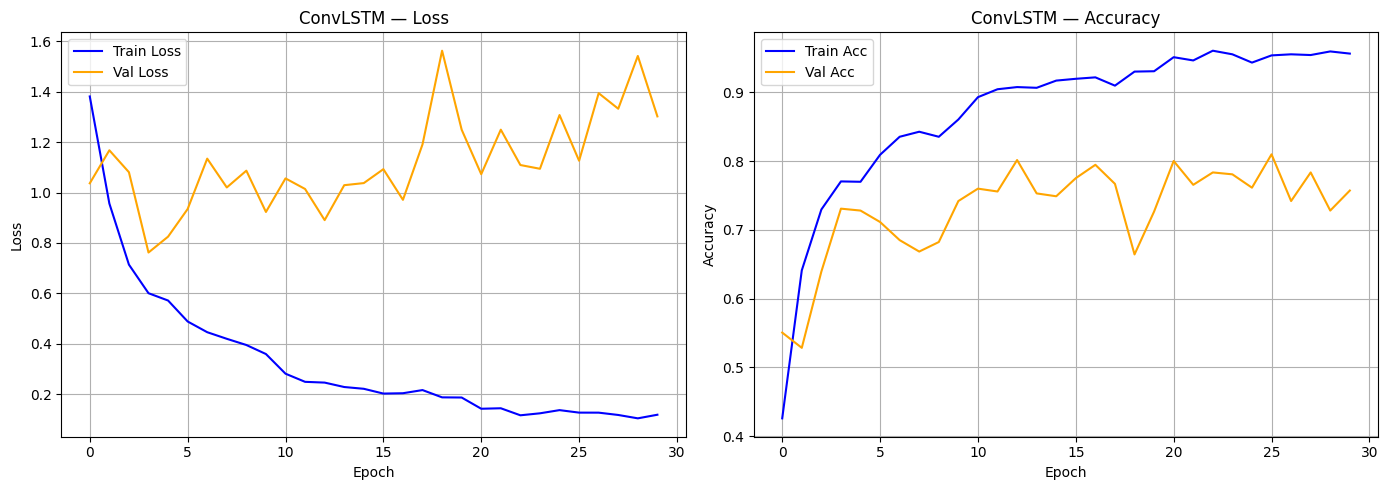

Saved training plot!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='orange')
axes[0].set_title('ConvLSTM — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train Acc', color='blue')
axes[1].plot(history['val_acc'],   label='Val Acc',   color='orange')
axes[1].set_title('ConvLSTM — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/convlstm_training.png', dpi=150)
plt.show()
print('Saved training plot!')

## Step 9: Evaluate on Test Set

In [9]:
model.load_state_dict(torch.load(f'{SAVE_DIR}/convlstm_best.pth'))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for X, y in test_loader:
        X     = X.to(device)
        out   = model(X)
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds, average='weighted')

print('='*50)
print('ConvLSTM — TEST RESULTS')
print('='*50)
print(f'Accuracy:          {acc:.4f}')
print(f'Weighted F1 Score: {f1:.4f}')
print()
print(classification_report(
    all_labels, all_preds,
    target_names=['No Stress', 'Watch', 'Warning', 'Alert L1', 'Alert L2']
))

ConvLSTM — TEST RESULTS
Accuracy:          0.8100
Weighted F1 Score: 0.8039

              precision    recall  f1-score   support

   No Stress       0.79      0.90      0.84       125
       Watch       0.92      0.60      0.73       237
     Warning       0.60      0.96      0.74        46
    Alert L1       0.76      0.72      0.74        53
    Alert L2       0.82      0.95      0.88       260

    accuracy                           0.81       721
   macro avg       0.78      0.82      0.79       721
weighted avg       0.83      0.81      0.80       721



## Step 10: Confusion Matrix

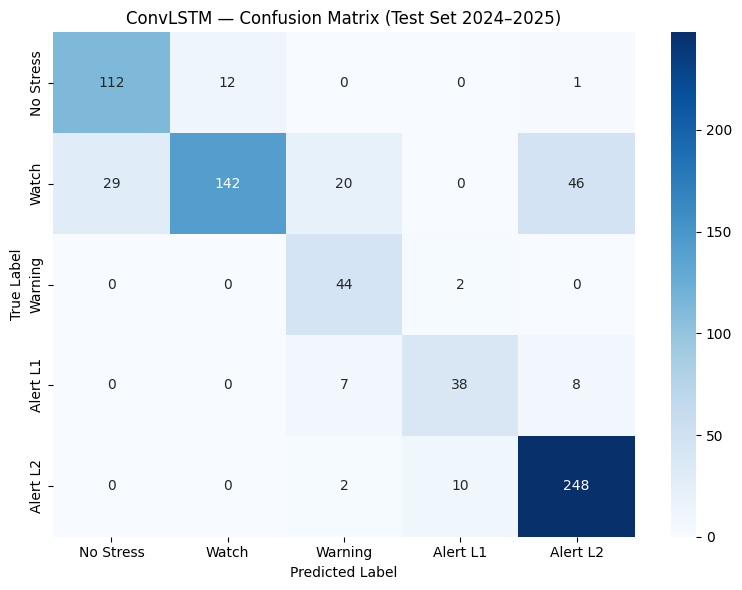

Saved confusion matrix!


In [10]:
cm     = confusion_matrix(all_labels, all_preds)
labels = ['No Stress', 'Watch', 'Warning', 'Alert L1', 'Alert L2']

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels
)
plt.title('ConvLSTM — Confusion Matrix (Test Set 2024–2025)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/convlstm_confusion.png', dpi=150)
plt.show()
print('Saved confusion matrix!')

## Step 11: Save Results

In [11]:
import json

results = {
    'model':       'ConvLSTM',
    'accuracy':    round(float(acc), 4),
    'f1_weighted': round(float(f1), 4),
    'best_val_acc': round(float(best_val_acc), 4),
    'epochs':      EPOCHS,
    'seq_len':     SEQ_LEN,
}

with open(f'{RESULTS_DIR}/convlstm_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Results saved!')
print(json.dumps(results, indent=2))

Results saved!
{
  "model": "ConvLSTM",
  "accuracy": 0.81,
  "f1_weighted": 0.8039,
  "best_val_acc": 0.81,
  "epochs": 30,
  "seq_len": 7
}


## Step 12: Download All Results to Laptop

In [12]:
from google.colab import files

print('Downloading results...')
files.download(f'{SAVE_DIR}/convlstm_best.pth')
files.download(f'{RESULTS_DIR}/convlstm_results.json')
files.download(f'{RESULTS_DIR}/convlstm_training.png')
files.download(f'{RESULTS_DIR}/convlstm_confusion.png')
print('All done! Check your Downloads folder.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All done! Check your Downloads folder.
